<a href="https://colab.research.google.com/github/vinasbhat/causalcell-foxp3-analysis/blob/main/CausalCell.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
print("hello Causalcell")
import pandas as pd
df = pd.read_excel("mmc5.xlsx")
df.head()
df.shape
df.columns
df["KO"].unique()


hello Causalcell


array(['AIRE', 'AKAP8', 'ARID5A', 'ATMIN', 'ATXN7L3', 'BACH2', 'BCL11B',
       'BPTF', 'CBFB', 'CLOCK', 'DR1', 'EGR3', 'ELK4', 'EPAS1', 'ETS1',
       'FOXK1', 'FOXP1', 'FOXP3', 'GATA3', 'GFI1', 'HIVEP2', 'HIVEP3',
       'IKZF1', 'IL2RA', 'IRF1', 'IRF2', 'IRF3', 'IRF4', 'IRF7', 'IRF8',
       'IRF9', 'JAK3', 'KLF2', 'KLF9', 'KMT2A', 'LCOR', 'MBD2', 'MED12',
       'MYB', 'MYSM1', 'NFAT5', 'NFE2L2', 'NFE2L3', 'NFKB1', 'NFKB2',
       'POU2F1', 'PTEN', 'RBCK1', 'REL', 'RELA', 'RELB', 'RFX5', 'RORC',
       'SETDB1', 'SON', 'SP110', 'SREBF1', 'STAT1', 'STAT2', 'STAT3',
       'STAT5A', 'STAT5B', 'TBX21', 'TCF3', 'TET2', 'TNFAIP3', 'TP53',
       'TTF1', 'YBX1', 'YBX3', 'YY1', 'ZBTB14', 'ZBTB24', 'ZFP3',
       'ZKSCAN1', 'ZNF217', 'ZNF319', 'ZNF329', 'ZNF331', 'ZNF341',
       'ZNF575', 'ZNF655', 'ZNF708', 'ZNF791'], dtype=object)

In [7]:

foxp3 = df[df["KO"]=="FOXP3"]
print (foxp3.shape)
print(foxp3.head())

(1007, 9)
                  gene_id gene_name     KO    baseMean  log2FoldChange  \
31109   ENSG00000248527.1  MTATP6P1  FOXP3  193.060399        0.242986   
31110  ENSG00000186891.14  TNFRSF18  FOXP3   48.792591       -0.365867   
31111   ENSG00000242485.6    MRPL20  FOXP3  303.687606        0.240258   
31112  ENSG00000157873.18  TNFRSF14  FOXP3  161.485429       -0.195650   
31113  ENSG00000007923.17   DNAJC11  FOXP3   32.631053        0.337619   

          lfcSE      stat    pvalue      padj  
31109  0.120010  2.024714  0.042897  0.461382  
31110  0.169640 -2.156722  0.031027       NaN  
31111  0.069339  3.464983  0.000530  0.099708  
31112  0.089137 -2.194943  0.028168  0.405724  
31113  0.167149  2.019864  0.043398       NaN  


In [9]:
foxp3_sorted = foxp3.sort_values(by="log2FoldChange" , ascending=False)
foxp3_sorted.head(10)

significant = foxp3[foxp3["padj"] < 0.05]

print(significant.shape)

significant.head()

(11, 9)


,gene_id,gene_name,KO,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
31154,ENSG00000116717.13,GADD45A,FOXP3,95.411285,-0.634852,0.131883,-4.813746,0.000001,0.002785
31161,ENSG00000154451.15,GBP5,FOXP3,1492.366130,-0.198956,0.047647,-4.175631,0.000030,0.021405
31258,ENSG00000081320.11,STK17B,FOXP3,1409.656060,-0.255207,0.052952,-4.819606,0.000001,0.002785
31327,ENSG00000172667.11,ZMAT3,FOXP3,312.080339,-0.340427,0.081622,-4.170781,0.000030,0.021405
31445,ENSG00000080546.14,SESN1,FOXP3,109.631001,-0.415846,0.103726,-4.009074,0.000061,0.031260


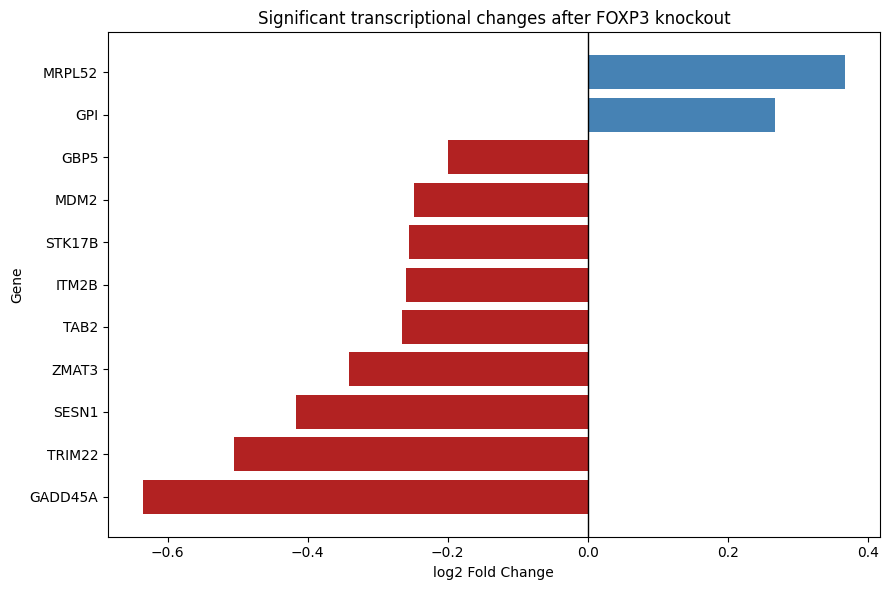

<Figure size 640x480 with 0 Axes>

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9,6))
colors = ["firebrick" if x < 0 else "steelblue" for x in significant["log2FoldChange"]]
plt.barh(significant["gene_name"],significant["log2FoldChange"],color=colors)
plt.axvline(0,color="black",linewidth=1)
plt.xlabel("log2 Fold Change")
plt.ylabel("Gene")
plt.title("Significant transcriptional changes after FOXP3 knockout")
plt.tight_layout()
plt.show()
plt.savefig("foxp3_plot.png", dpi=300, bbox_inches="tight")